# CICIDS-2017 CSV → XGBoost / TCN Inference Pipeline
### Network Intrusion Detection — CICIDS-2017 Dataset Evaluation

This notebook loads the pre-extracted **CICIDS-2017** flow CSVs from `./TrafficLabelling/`,
applies the same feature engineering as the training pipeline,
then runs **XGBoost** and **TCN** inference independently against saved models in `models/`.

| Cell | Purpose |
|------|---------|
| 1 | Install & import libraries |
| 2 | Configuration |
| 3 | Load & merge all CICIDS-2017 CSVs |
| 4 | Feature engineering |
| 5 | PowerTransformer scaling |
| 6 | XGBoost inference |
| 7 | TCN sequence building + inference |
| 8 | Alert summary & visualisations |
| 9 | Export results to CSV |

## Cell 1 — Install & Import Libraries

In [1]:
import subprocess, sys

pkgs = [
    "pandas", "numpy", "scikit-learn",
    "xgboost", "tensorflow", "keras-tcn",
    "joblib", "h5py", "scipy", "tqdm", "tqdm[notebook]", "matplotlib", "seaborn",
]
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkgs)
print("✅ Packages ready")

✅ Packages ready



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import gc, math, os, sys, warnings

import numpy  as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy as scipy_entropy
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 20)
print("✅ Core libraries imported")

✅ Core libraries imported


## Cell 2 — Configuration

Edit the paths and thresholds here before running the rest of the notebook.

In [3]:
# ── Paths ─────────────────────────────────────────────────────────────
TRAFFIC_DIR = "./TrafficLabelling "   # ← folder containing all CICIDS-2017 CSVs
MODEL_DIR   = "./models"             # ← directory with saved model artefacts
OUTPUT_DIR  = "./outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── CSV files to load (set to None to load ALL csvs in TRAFFIC_DIR) ──
CSV_FILES = None   # None = auto-discover all *.csv in TRAFFIC_DIR

# ── Inference mode ────────────────────────────────────────────────────
MODE = "both"

# ── Decision thresholds ───────────────────────────────────────────────
XGB_THRESHOLD = 0.2
TCN_THRESHOLD = 0.022

# ── Sequence / batch knobs (must match training) ──────────────────────
SEQ_LEN    = 20
BATCH_SIZE = 512

# ── Feature lists (must match training exactly) ────────────────────────
NUMERIC_FEATURES = [
    "Dur", "TotPkts", "TotBytes", "SrcBytes",
    "BytesPerPkt", "PktRate", "ByteRate", "SrcBytesRatio",
]
ENCODED_FEATURES = ["Proto_enc", "Sport_cat", "Dport_cat", "Dir_enc"]
ALL_FEATURES     = NUMERIC_FEATURES + ENCODED_FEATURES   # 12 dims

INTERACTION_NAMES = [
    "byte_per_pkt_rate", "src_dominance_dur", "port_symmetry",
    "pkt_density", "proto_dport_cross", "byte_asym_mag",
]

N_WITHIN = 7   # within-window TCN features appended per sequence
EPSILON  = 1e-9

# ── Column mapping: CICIDS-2017 → training schema ─────────────────────
CICIDS_COL_MAP = {
    " Flow Duration":       "Dur",
    " Total Fwd Packets":   "FwdPkts",
    " Total Backward Packets": "BwdPkts",
    " Total Length of Fwd Packets": "FwdBytes",
    " Total Length of Bwd Packets": "BwdBytes",
    " Source IP":           "SrcAddr",
    " Source Port":         "Sport",
    " Destination IP":      "DstAddr",
    " Destination Port":    "Dport",
    " Protocol":            "Proto",
    " Timestamp":           "StartTime",
    " Label":               "Label",
    "Flow Duration":        "Dur",
    "Total Fwd Packets":    "FwdPkts",
    "Total Backward Packets": "BwdPkts",
    "Total Length of Fwd Packets": "FwdBytes",
    "Total Length of Bwd Packets": "BwdBytes",
    "Source IP":            "SrcAddr",
    "Source Port":          "Sport",
    "Destination IP":       "DstAddr",
    "Destination Port":     "Dport",
    "Protocol":             "Proto",
    "Timestamp":            "StartTime",
    "Label":                "Label",
}

print("✅ Configuration set")
print(f"   TRAFFIC_DIR : {TRAFFIC_DIR}")
print(f"   MODEL_DIR   : {MODEL_DIR}")
print(f"   MODE        : {MODE}")
print(f"   Thresholds  : XGB={XGB_THRESHOLD}  TCN={TCN_THRESHOLD}")


✅ Configuration set
   TRAFFIC_DIR : ./TrafficLabelling 
   MODEL_DIR   : ./models
   MODE        : both
   Thresholds  : XGB=0.2  TCN=0.022


## Cell 3 — Load & Merge All CICIDS-2017 CSVs

Reads all eight day-files, normalises column names to the BinetFlow schema,
derives `TotPkts`, `TotBytes`, `SrcBytes` and a dummy `Dir` column,
then concatenates into one DataFrame.

In [4]:
from tqdm.auto import tqdm


def discover_csv_files(traffic_dir: str, specified: list = None) -> list:
    """Return sorted list of CSV paths to load."""
    if specified:
        return [os.path.join(traffic_dir, f) for f in specified]
    files = sorted(
        os.path.join(traffic_dir, f)
        for f in os.listdir(traffic_dir)
        if f.lower().endswith(".csv")
    )
    if not files:
        raise FileNotFoundError(f"No CSV files found in {traffic_dir!r}")
    return files


def load_cicids_csv(path: str, col_map: dict) -> pd.DataFrame:
    """
    Load one CICIDS-2017 CICFlowMeter CSV and normalise it to
    the BinetFlow-compatible schema used by the inference pipeline.

    Derived columns
    ---------------
    TotPkts   = FwdPkts  + BwdPkts
    TotBytes  = FwdBytes + BwdBytes
    SrcBytes  = FwdBytes  (forward direction = source → destination)
    Dur       = Flow Duration (µs) → seconds
    Dir       = "->"  (constant; no bidirectional flag in CICIDS)
    """
    df = pd.read_csv(path, low_memory=False)

    # Strip leading/trailing whitespace from column names
    df.columns = df.columns.str.strip()

    # Rename using the map (only present columns)
    rename = {k.strip(): v for k, v in col_map.items() if k.strip() in df.columns}
    df.rename(columns=rename, inplace=True)

    # ── Derived columns ───────────────────────────────────────────────
    # TotPkts
    if "TotPkts" not in df.columns:
        fwd = pd.to_numeric(df.get("FwdPkts",  pd.Series(0, index=df.index)), errors="coerce").fillna(0)
        bwd = pd.to_numeric(df.get("BwdPkts",  pd.Series(0, index=df.index)), errors="coerce").fillna(0)
        df["TotPkts"] = (fwd + bwd).astype(np.int32)

    # TotBytes
    if "TotBytes" not in df.columns:
        fwdb = pd.to_numeric(df.get("FwdBytes", pd.Series(0, index=df.index)), errors="coerce").fillna(0)
        bwdb = pd.to_numeric(df.get("BwdBytes", pd.Series(0, index=df.index)), errors="coerce").fillna(0)
        df["TotBytes"]  = (fwdb + bwdb).astype(np.int32)
        df["SrcBytes"]  = fwdb.astype(np.int32)   # forward = source bytes
    elif "SrcBytes" not in df.columns:
        fwdb = pd.to_numeric(df.get("FwdBytes", pd.Series(0, index=df.index)), errors="coerce").fillna(0)
        df["SrcBytes"] = fwdb.astype(np.int32)

    # Duration: CICIDS stores in microseconds → convert to seconds
    if "Dur" in df.columns:
        df["Dur"] = pd.to_numeric(df["Dur"], errors="coerce").fillna(0) / 1e6

    # Direction placeholder
    if "Dir" not in df.columns:
        df["Dir"] = "->"

    # Protocol: CICIDS encodes as integer (6=TCP, 17=UDP, 0=HOPOPT/Other)
    if "Proto" in df.columns:
        proto_map = {"6": "tcp", "17": "udp", "1": "icmp", 6: "tcp", 17: "udp", 1: "icmp"}
        df["Proto"] = df["Proto"].apply(
            lambda x: proto_map.get(x, proto_map.get(str(int(float(x)))
                                    if str(x).replace(".", "").isdigit() else x, "other"))
        )

    # Sport / Dport as strings
    for col in ("Sport", "Dport"):
        if col in df.columns:
            df[col] = df[col].astype(str)

    # StartTime: parse CICIDS timestamp strings
    if "StartTime" in df.columns:
        df["StartTime"] = pd.to_datetime(df["StartTime"], errors="coerce", dayfirst=True)

    # Fill missing address columns with placeholders
    for col in ("SrcAddr", "DstAddr"):
        if col not in df.columns:
            df[col] = "0.0.0.0"

    # Keep a source-file tag for later analysis
    df["_source_file"] = os.path.basename(path)

    return df


# ── Discover & load ───────────────────────────────────────────────────
csv_paths = discover_csv_files(TRAFFIC_DIR, CSV_FILES)
print(f"Found {len(csv_paths)} CSV file(s):")
for p in csv_paths:
    size_mb = os.path.getsize(p) / 1e6
    print(f"  {os.path.basename(p):<60}  {size_mb:7.1f} MB")

chunks = []
for path in tqdm(csv_paths, desc="Loading CSVs"):
    try:
        df_day = load_cicids_csv(path, CICIDS_COL_MAP)
        chunks.append(df_day)
        print(f"  ✅ {os.path.basename(path):<55} {len(df_day):>8,} rows")
    except Exception as exc:
        print(f"  ⚠ Skipped {os.path.basename(path)}: {exc}")

df_raw = pd.concat(chunks, ignore_index=True)
del chunks; gc.collect()

print(f"\nCombined shape  : {df_raw.shape}")
print(f"Label counts    :")
if "Label" in df_raw.columns:
    print(df_raw["Label"].value_counts().to_string())
df_raw.head(3)

Found 8 CSV file(s):
  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv                 96.1 MB
  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv            101.9 MB
  Friday-WorkingHours-Morning.pcap_ISCX.csv                        75.4 MB
  Monday-WorkingHours.pcap_ISCX.csv                               268.6 MB
  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv     108.7 MB
  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv           92.0 MB
  Tuesday-WorkingHours.pcap_ISCX.csv                              174.7 MB
  Wednesday-workingHours.pcap_ISCX.csv                            285.6 MB


Loading CSVs:   0%|          | 0/8 [00:00<?, ?it/s]

  ✅ Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv         225,745 rows
  ✅ Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv     286,467 rows
  ✅ Friday-WorkingHours-Morning.pcap_ISCX.csv                191,033 rows
  ✅ Monday-WorkingHours.pcap_ISCX.csv                        529,918 rows
  ✅ Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv  288,602 rows
  ⚠ Skipped Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv: 'utf-8' codec can't decode byte 0x96 in position 22398: invalid start byte
  ✅ Tuesday-WorkingHours.pcap_ISCX.csv                       445,909 rows
  ✅ Wednesday-workingHours.pcap_ISCX.csv                     692,703 rows

Combined shape  : (2660377, 90)
Label counts    :
Label
BENIGN              2104911
DoS Hulk             231073
PortScan             158930
DDoS                 128027
DoS GoldenEye         10293
FTP-Patator            7938
SSH-Patator            5897
DoS slowloris          5796
DoS Slowhttptest       5499
Bot                    196

,Flow ID,SrcAddr,Sport,DstAddr,Dport,Proto,StartTime,Dur,FwdPkts,BwdPkts,...,Idle Mean,Idle Std,Idle Max,Idle Min,Label,TotPkts,TotBytes,SrcBytes,Dir,_source_file
0,192.168.10.5-104.16.207.165-54865-443-6,104.16.207.165,443,192.168.10.5,54865,tcp,2017-07-07 03:30:00,0.000003,2,0,...,0.0,0.0,0.0,0.0,BENIGN,2,12,12,->,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
1,192.168.10.5-104.16.28.216-55054-80-6,104.16.28.216,80,192.168.10.5,55054,tcp,2017-07-07 03:30:00,0.000109,1,1,...,0.0,0.0,0.0,0.0,BENIGN,2,12,6,->,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
2,192.168.10.5-104.16.28.216-55055-80-6,104.16.28.216,80,192.168.10.5,55055,tcp,2017-07-07 03:30:00,0.000052,1,1,...,0.0,0.0,0.0,0.0,BENIGN,2,12,6,->,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


## Cell 4 — Feature Engineering

Exact mirror of the training pipeline:
- Numeric coercion + inf removal
- Behavioral ratios: `BytesPerPkt`, `PktRate`, `ByteRate`, `SrcBytesRatio`
- P99 clipping using **training** bounds from `models/clip_bounds.pkl`
- Protocol / direction / port encoding
- Per-flow IAT (inter-arrival time within each source IP)
- `flow_asymmetry` (per-row src vs dst byte imbalance)

In [5]:
# ── Load training artefacts ───────────────────────────────────────────
clip_bounds = joblib.load(os.path.join(MODEL_DIR, "clip_bounds.pkl"))
scaler      = joblib.load(os.path.join(MODEL_DIR, "scaler.pkl"))
le_proto    = joblib.load(os.path.join(MODEL_DIR, "le_proto.pkl"))
le_dir      = joblib.load(os.path.join(MODEL_DIR, "le_dir.pkl"))
# FIX 2/3: the TCN was trained on within-window features that were scaled
# with a RobustScaler (win_scaler.pkl), clipped to [-4, 4] — see training
# Cell 9b "STEP 4 — Fit within-window scaler". Inference must load and
# apply the SAME scaler before calling the model, or the 7 within-window
# dims arrive in raw, unscaled units the model never saw during training.
win_scaler  = joblib.load(os.path.join(MODEL_DIR, "win_scaler.pkl"))
print(f"clip_bounds loaded : {len(clip_bounds)} columns → {list(clip_bounds.keys())}")
print(f"scaler loaded      : {type(scaler).__name__}")
print(f"le_proto loaded    : classes = {list(le_proto.classes_)}")
print(f"le_dir loaded      : classes = {list(le_dir.classes_)}")
print(f"win_scaler loaded  : {type(win_scaler).__name__}")


clip_bounds loaded : 7 columns → ['Dur', 'TotPkts', 'TotBytes', 'SrcBytes', 'BytesPerPkt', 'PktRate', 'ByteRate']
scaler loaded      : PowerTransformer
le_proto loaded    : classes = ['arp', 'esp', 'gre', 'icmp', 'igmp', 'ipnip', 'ipv6', 'ipv6-icmp', 'ipx/spx', 'llc', 'pim', 'rarp', 'rsvp', 'rtcp', 'rtp', 'tcp', 'udp', 'udt', 'unas']
le_dir loaded      : classes = ['->', '<-', '<->', '<?', '<?>', '?>', 'who']
win_scaler loaded  : RobustScaler


In [6]:
def _categorize_port(p) -> int:
    """Map raw port to the 6-category encoding used in training."""
    try:
        p = int(float(str(p).strip()))
        if p in (443, 80): return 4   # HTTPS / HTTP
        if p == 53:        return 5   # DNS
        if p <= 1023:      return 0   # well-known
        if p <= 49151:     return 1   # registered
        return 2                       # ephemeral
    except Exception:
        return 3                       # unparseable


def engineer_features(df: pd.DataFrame,
                      clip_bounds: dict,
                      le_proto: LabelEncoder,
                      le_dir: LabelEncoder) -> pd.DataFrame:
    """
    Apply all feature engineering steps from training.
    Returns a DataFrame with ALL_FEATURES + TCN helper columns.
    """
    df = df.copy()

    # ── 1. Numerics ───────────────────────────────────────────────────
    for col in ["Dur", "TotPkts", "TotBytes", "SrcBytes"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(subset=["Dur", "TotPkts", "TotBytes", "SrcBytes"], inplace=True)
    df.reset_index(drop=True, inplace=True)

    # ── 2. Behavioral ratios ──────────────────────────────────────────
    df["BytesPerPkt"]   = (df["TotBytes"] / (df["TotPkts"]  + EPSILON)).astype(np.float32)
    df["PktRate"]       = (df["TotPkts"]  / (df["Dur"]      + EPSILON)).astype(np.float32)
    df["ByteRate"]      = (df["TotBytes"] / (df["Dur"]      + EPSILON)).astype(np.float32)
    df["SrcBytesRatio"] = (df["SrcBytes"] / (df["TotBytes"] + EPSILON)).clip(0, 1).astype(np.float32)

    # ── 3. P99 clip (training bounds) ─────────────────────────────────
    CLIP_COLS = ["Dur", "TotPkts", "TotBytes", "SrcBytes",
                 "BytesPerPkt", "PktRate", "ByteRate"]
    for col in CLIP_COLS:
        if col in clip_bounds:
            df[col] = df[col].clip(upper=clip_bounds[col]).astype(np.float32)

    # ── 4. Protocol encoding ──────────────────────────────────────────
    proto_str = df["Proto"].astype(str).str.lower().str.strip()
    unknown_protos = set(proto_str.unique()) - set(le_proto.classes_)
    if unknown_protos:
        print(f"  ⚠ Unknown proto values mapped to '{le_proto.classes_[0]}': {unknown_protos}")
        proto_str = proto_str.apply(
            lambda x: x if x in le_proto.classes_ else le_proto.classes_[0]
        )
    df["Proto_enc"] = le_proto.transform(proto_str).astype(np.int16)

    # ── 5. Direction encoding ─────────────────────────────────────────
    if "Dir" in df.columns:
        dir_str = df["Dir"].astype(str).str.strip()
        unknown_dirs = set(dir_str.unique()) - set(le_dir.classes_)
        if unknown_dirs:
            print(f"  ⚠ Unknown Dir values mapped to '{le_dir.classes_[0]}': {unknown_dirs}")
            dir_str = dir_str.apply(
                lambda x: x if x in le_dir.classes_ else le_dir.classes_[0]
            )
        df["Dir_enc"] = le_dir.transform(dir_str).astype(np.int16)
    else:
        df["Dir_enc"] = np.int16(0)

    # ── 6. Port categories ────────────────────────────────────────────
    df["Sport_cat"] = df["Sport"].apply(_categorize_port).astype(np.int8)
    df["Dport_cat"] = df["Dport"].apply(_categorize_port).astype(np.int8)

    # ── 7. StartTime → Unix epoch ─────────────────────────────────────
    df["StartTime_epoch"] = (
        pd.to_datetime(df["StartTime"], errors="coerce")
        .astype(np.int64) // 10**9
    ).astype(np.float64)

    # ── 8. Sort by IP + time (required for IAT + TCN sequencing) ──────
    df.sort_values(["SrcAddr", "StartTime_epoch"], inplace=True)
    df.reset_index(drop=True, inplace=True)

    # ── 9. Per-flow IAT ───────────────────────────────────────────────
    df["IAT_raw"] = (
        df.groupby("SrcAddr")["StartTime_epoch"]
        .diff()
        .fillna(0)
        .astype(np.float32)
    )

    # ── 10. Flow asymmetry ────────────────────────────────────────────
    src_b = df["SrcBytes"].astype(np.float32)
    dst_b = (df["TotBytes"] - df["SrcBytes"]).astype(np.float32)
    df["flow_asymmetry"] = (
        (src_b - dst_b).abs() / (df["TotBytes"].astype(np.float32) + EPSILON)
    ).astype(np.float32)

    # ── 11. Drop raw helpers no longer needed ─────────────────────────
    df.drop(columns=["Proto", "Dir", "Sport", "StartTime"],
            inplace=True, errors="ignore")
    df.dropna(subset=ALL_FEATURES, inplace=True)
    df.reset_index(drop=True, inplace=True)

    return df


# ── Run ───────────────────────────────────────────────────────────────
print("Engineering features …")
df_feat = engineer_features(df_raw, clip_bounds, le_proto=le_proto, le_dir=le_dir)
print(f"\nEngineered shape : {df_feat.shape}")
print(f"Columns          : {list(df_feat.columns)}")
df_feat[ALL_FEATURES].describe().round(3)

Engineering features …
  ⚠ Unknown proto values mapped to 'arp': {'other'}

Engineered shape : (2660377, 97)
Columns          : ['Flow ID', 'SrcAddr', 'DstAddr', 'Dport', 'Dur', 'FwdPkts', 'BwdPkts', 'FwdBytes', 'BwdBytes', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag 

,Dur,TotPkts,TotBytes,SrcBytes,BytesPerPkt,PktRate,ByteRate,SrcBytesRatio,Proto_enc,Sport_cat,Dport_cat,Dir_enc
count,2660377.000,2660377.000,2660377.000,2660377.000,2660377.000,2.660377e+06,2.660377e+06,2660377.000,2660377.000,2660377.000,2660377.000,2660377.0
mean,14.934,9.704,3913.350,451.498,176.045,1.098714e+06,8.867173e+06,0.333,15.336,1.971,3.597,0.0
std,33.755,20.502,13652.616,1597.566,292.104,3.202789e+07,4.568749e+08,0.326,0.603,0.955,1.524,0.0
min,-0.000,2.000,0.000,0.000,0.000,-2.002002e+06,-1.931932e+08,0.000,0.000,0.000,0.000,0.0
25%,0.000,2.000,12.000,6.000,6.000,3.276000e+00,1.190940e+02,0.031,15.000,1.000,2.000,0.0
50%,0.031,4.000,208.000,62.000,61.500,1.126510e+02,4.570745e+03,0.250,15.000,2.000,4.000,0.0
75%,3.393,8.000,1315.000,196.000,137.500,2.352927e+04,1.632620e+05,0.435,16.000,2.000,5.000,0.0
max,120.000,212.000,136696.859,15774.000,1011.884,1.000000e+09,1.450000e+11,1.000,16.000,5.000,5.000,0.0


## Cell 5 — PowerTransformer Scaling

Applies the **training** `PowerTransformer` (Yeo-Johnson) to the 12 base
`ALL_FEATURES` and clips to `[-4, 4]` — exactly as training Cell 7.

## Cell 5a — Byte-Feature Scaler Adaptation

Re-fits the PowerTransformer's Yeo-Johnson lambdas **only for the three byte columns** (`TotBytes`, `SrcBytes`, `BytesPerPkt`) on CICIDS data, leaving all other feature lambdas from the CTU-13 training scaler untouched. This corrects for the systematic distribution shift in byte counts between NetFlow (CTU-13) and CICFlowMeter (CICIDS-2017).

In [7]:
from sklearn.preprocessing import PowerTransformer
import copy

BYTE_COLS    = ["TotBytes", "SrcBytes", "BytesPerPkt"]
BYTE_IDXS    = [FEATURES_FOR_SCALER.index(c) if 'FEATURES_FOR_SCALER' in dir() else
                (NUMERIC_FEATURES + ENCODED_FEATURES).index(c) for c in BYTE_COLS]

scaler_adapted = copy.deepcopy(scaler)

byte_pt    = PowerTransformer(method="yeo-johnson", standardize=True)
sample     = df_feat[BYTE_COLS].replace([np.inf, -np.inf], np.nan).dropna()
sample_fit = sample.sample(min(200_000, len(sample)), random_state=42).values.astype(np.float64)
byte_pt.fit(sample_fit)

# PowerTransformer stores normalisation stats in _scaler (internal StandardScaler)
for pos, col_idx in enumerate(BYTE_IDXS):
    scaler_adapted.lambdas_[col_idx]         = byte_pt.lambdas_[pos]
    scaler_adapted._scaler.mean_[col_idx]    = byte_pt._scaler.mean_[pos]
    scaler_adapted._scaler.var_[col_idx]     = byte_pt._scaler.var_[pos]
    scaler_adapted._scaler.scale_[col_idx]   = byte_pt._scaler.scale_[pos]

print("Adapted scaler — refit lambdas for byte columns:")
for pos, col in enumerate(BYTE_COLS):
    orig_lam = scaler.lambdas_[BYTE_IDXS[pos]]
    new_lam  = scaler_adapted.lambdas_[BYTE_IDXS[pos]]
    print(f"  {col:<16}  lambda: {orig_lam:.4f} → {new_lam:.4f}")

print("\nNon-byte columns: lambdas unchanged (CTU-13 scaler kept)")
scaler = scaler_adapted
print("✅ scaler replaced with adapted version")


Adapted scaler — refit lambdas for byte columns:
  TotBytes          lambda: -0.4087 → 0.0063
  SrcBytes          lambda: -0.0793 → 0.0159
  BytesPerPkt       lambda: -0.6409 → 0.0640

Non-byte columns: lambdas unchanged (CTU-13 scaler kept)
✅ scaler replaced with adapted version


In [8]:
# ALL_FEATURES must stay 12-dim to match the PowerTransformer.
# Dir_enc is constant in CICIDS (all "->"), so we scale normally
# then overwrite it with 0.0 (neutral) post-transform.
FEATURES_FOR_SCALER = NUMERIC_FEATURES + ENCODED_FEATURES  # always 12

CHUNK = 200_000
scaled_arr = np.empty((len(df_feat), len(FEATURES_FOR_SCALER)), dtype=np.float32)

for start in range(0, len(df_feat), CHUNK):
    end   = min(start + CHUNK, len(df_feat))
    chunk = df_feat[FEATURES_FOR_SCALER].iloc[start:end].values.astype(np.float32)
    scaled_arr[start:end] = np.clip(scaler.transform(chunk), -4, 4).astype(np.float32)

# Zero out Dir_enc — constant in CICIDS, no discriminative signal
dir_idx = FEATURES_FOR_SCALER.index("Dir_enc")
scaled_arr[:, dir_idx] = 0.0
print("Dir_enc zeroed out post-scaling (constant in CICIDS)")

df_scaled = df_feat.copy()
for i, col in enumerate(FEATURES_FOR_SCALER):
    df_scaled[col] = scaled_arr[:, i]

# Keep unscaled TotBytes for TCN within-window payload CV computation
df_scaled["TotBytes_raw"] = df_feat["TotBytes"].values

# Restore ALL_FEATURES to full 12-dim so downstream cells stay consistent
ALL_FEATURES = FEATURES_FOR_SCALER

rng = scaled_arr.min(), scaled_arr.max()
print(f"✅ Scaling complete   range=[{rng[0]:.3f}, {rng[1]:.3f}]")
if rng[1] > 10 or rng[0] < -10:
    print("⛔  WARNING: scaling looks wrong — check scaler.pkl")
else:
    print("   Range healthy (within ±4)")

print("\n=== DOMAIN-SHIFT DIAGNOSTIC: % values at ±4 clip boundary ===")
near_bound = np.abs(scaled_arr) >= 3.999
for i, col in enumerate(FEATURES_FOR_SCALER):
    pct = 100.0 * near_bound[:, i].mean()
    flag = "  ⚠ likely shifted" if pct > 10 else ("  ⚠ watch" if pct > 2 else "")
    print(f"  {col:<16} {pct:6.2f}%{flag}")

del scaled_arr, near_bound; gc.collect()


Dir_enc zeroed out post-scaling (constant in CICIDS)
✅ Scaling complete   range=[-4.000, 3.157]
   Range healthy (within ±4)

=== DOMAIN-SHIFT DIAGNOSTIC: % values at ±4 clip boundary ===
  Dur                0.00%
  TotPkts            0.00%
  TotBytes           0.00%
  SrcBytes           0.00%
  BytesPerPkt        0.00%
  PktRate            0.00%
  ByteRate           0.00%
  SrcBytesRatio      0.00%
  Proto_enc          0.06%
  Sport_cat          1.59%
  Dport_cat          0.00%
  Dir_enc            0.00%


0

## Cell 6 — XGBoost Inference

Appends the 6 interaction features, then calls `predict_proba` on every flow.
Result: per-flow `xgb_prob` and `xgb_alert`.

In [9]:
def add_xgb_interactions(X: np.ndarray, feature_names: list):
    """
    Append 6 engineered interaction features.
    Exact replica of the training pipeline's Cell 8.
    """
    eps = EPSILON
    idx = {f: i for i, f in enumerate(feature_names)}

    dur       = X[:, idx["Dur"]]
    tot_pkts  = X[:, idx["TotPkts"]]
    tot_bytes = X[:, idx["TotBytes"]]
    pkt_rate  = X[:, idx["PktRate"]]
    byte_rate = X[:, idx["ByteRate"]]
    src_ratio = X[:, idx["SrcBytesRatio"]]
    sport     = X[:, idx["Sport_cat"]]
    dport     = X[:, idx["Dport_cat"]]
    proto     = X[:, idx["Proto_enc"]]

    interactions = np.column_stack([
        np.clip(byte_rate / (pkt_rate + eps), 0, 1e4),
        src_ratio * np.log1p(dur),
        (sport == dport).astype(np.float32),
        np.clip(tot_pkts / (tot_bytes + eps), 0, 1e3),
        proto * 10 + dport,
        np.clip(np.abs(2 * src_ratio - 1), 0, 1),
    ]).astype(np.float32)

    aug_names = feature_names + INTERACTION_NAMES
    return np.hstack([X, interactions]), aug_names

In [10]:
xgb_results = None

if MODE in ("xgb", "both"):
    import xgboost as xgb
    from sklearn.metrics import (
        precision_recall_curve, roc_auc_score, average_precision_score,
    )

    xgb_model = joblib.load(os.path.join(MODEL_DIR, "xgb_model.pkl"))
    print(f"XGBoost loaded  (best_iter={getattr(xgb_model, 'best_iteration', '?')})")

    X_base = df_scaled[ALL_FEATURES].values.astype(np.float32)
    X_aug, aug_names = add_xgb_interactions(X_base, list(ALL_FEATURES))
    print(f"Feature matrix  : {X_aug.shape}  ({len(ALL_FEATURES)} base + 6 interactions)")

    xgb_probs = xgb_model.predict_proba(X_aug)[:, 1].astype(np.float32)

    print("\n=== XGBOOST OUTPUT DIAGNOSTIC ===")
    print(f"Min  : {xgb_probs.min():.6f}")
    print(f"Max  : {xgb_probs.max():.6f}")
    print(f"Mean : {xgb_probs.mean():.6f}")
    print(f"Std  : {xgb_probs.std():.6f}")
    print("Percentiles [1,5,10,25,50,75,90,95,99]:")
    print(np.percentile(xgb_probs, [1, 5, 10, 25, 50, 75, 90, 95, 99]).round(6))

    keep_cols = [c for c in ["SrcAddr", "DstAddr", "Label", "_source_file"]
                 if c in df_scaled.columns]
    xgb_results = df_scaled[keep_cols].copy()
    xgb_results["xgb_prob"] = xgb_probs

    if "Label" in xgb_results.columns:
        xgb_results["is_attack_gt"] = (
            ~xgb_results["Label"].str.upper().str.contains("BENIGN")
        ).astype(int)

        ben_mean = xgb_probs[xgb_results["is_attack_gt"] == 0].mean()
        mal_mean = xgb_probs[xgb_results["is_attack_gt"] == 1].mean()
        sep = mal_mean / (ben_mean + 1e-9)
        print(f"\nBenign    prob mean : {ben_mean:.4f}")
        print(f"Malicious prob mean : {mal_mean:.4f}")
        print(f"Separation ratio    : {sep:.2f}x  "
              f"(5-50x credible; near 1x signals little/no transfer)")

        prec_arr, rec_arr, thr = precision_recall_curve(xgb_results["is_attack_gt"], xgb_probs)
        beta = 2.0
        fb   = ((1 + beta**2) * prec_arr[:-1] * rec_arr[:-1]
                / (beta**2 * prec_arr[:-1] + rec_arr[:-1] + 1e-9))
        best = int(np.argmax(fb))
        xgb_thresh_used = float(thr[best])
        print(f"\n✅ Empirical F2-optimal threshold (this run) : {xgb_thresh_used:.4f}"
              f"   (config XGB_THRESHOLD={XGB_THRESHOLD} kept only as a reference)")

        y_true_xgb = xgb_results["is_attack_gt"].values
        if len(np.unique(y_true_xgb)) > 1:
            xgb_auc   = roc_auc_score(y_true_xgb, xgb_probs)
            xgb_prauc = average_precision_score(y_true_xgb, xgb_probs)
            print(f"   ROC-AUC  : {xgb_auc:.4f}")
            print(f"   PR-AUC   : {xgb_prauc:.4f}")
        else:
            print("   ⚠ Only one class present — AUC/PR-AUC skipped.")
    else:
        xgb_thresh_used = XGB_THRESHOLD
        print(f"\nNo Label column — using config XGB_THRESHOLD={XGB_THRESHOLD}")

    xgb_results["xgb_alert"] = (xgb_probs >= xgb_thresh_used).astype(int)

    n_alert = xgb_results["xgb_alert"].sum()
    print(f"\n✅ XGBoost → {n_alert:,} alerts / {len(xgb_results):,} flows  "
          f"(threshold={xgb_thresh_used:.4f})")

    if "is_attack_gt" in xgb_results.columns:
        tp = ((xgb_results["xgb_alert"] == 1) & (xgb_results["is_attack_gt"] == 1)).sum()
        fp = ((xgb_results["xgb_alert"] == 1) & (xgb_results["is_attack_gt"] == 0)).sum()
        fn = ((xgb_results["xgb_alert"] == 0) & (xgb_results["is_attack_gt"] == 1)).sum()
        prec_v = tp / (tp + fp + 1e-9)
        rec_v  = tp / (tp + fn + 1e-9)
        f1_v   = 2 * prec_v * rec_v / (prec_v + rec_v + 1e-9)
        print(f"   Ground-truth: TP={tp:,}  FP={fp:,}  FN={fn:,}")
        print(f"   Precision={prec_v:.4f}  Recall={rec_v:.4f}  F1={f1_v:.4f}")

        static_alert = (xgb_probs >= XGB_THRESHOLD).astype(int)
        tp_s = ((static_alert == 1) & (xgb_results["is_attack_gt"] == 1)).sum()
        fp_s = ((static_alert == 1) & (xgb_results["is_attack_gt"] == 0)).sum()
        fn_s = ((static_alert == 0) & (xgb_results["is_attack_gt"] == 1)).sum()
        prec_s = tp_s / (tp_s + fp_s + 1e-9)
        rec_s  = tp_s / (tp_s + fn_s + 1e-9)
        f1_s   = 2 * prec_s * rec_s / (prec_s + rec_s + 1e-9)
        print(f"\n   [Reference] static XGB_THRESHOLD={XGB_THRESHOLD}:  "
              f"Precision={prec_s:.4f}  Recall={rec_s:.4f}  F1={f1_s:.4f}")

    xgb_results.head(5)
else:
    print("Skipping XGBoost (MODE=%s)" % MODE)


XGBoost loaded  (best_iter=167)
Feature matrix  : (2660377, 18)  (12 base + 6 interactions)

=== XGBOOST OUTPUT DIAGNOSTIC ===
Min  : 0.000051
Max  : 0.934087
Mean : 0.035070
Std  : 0.113550
Percentiles [1,5,10,25,50,75,90,95,99]:
[9.70000e-05 1.15000e-04 1.28000e-04 1.82000e-04 3.61000e-04 1.23300e-03
 9.04710e-02 2.31146e-01 6.47580e-01]

Benign    prob mean : 0.0356
Malicious prob mean : 0.0331
Separation ratio    : 0.93x  (5-50x credible; near 1x signals little/no transfer)

✅ Empirical F2-optimal threshold (this run) : 0.0001   (config XGB_THRESHOLD=0.2 kept only as a reference)
   ROC-AUC  : 0.5798
   PR-AUC   : 0.2559

✅ XGBoost → 2,582,404 alerts / 2,660,377 flows  (threshold=0.0001)
   Ground-truth: TP=548,560  FP=2,033,844  FN=6,906
   Precision=0.2124  Recall=0.9876  F1=0.3496

   [Reference] static XGB_THRESHOLD=0.2:  Precision=0.2319  Recall=0.0679  F1=0.1050


## Cell 6b — XGBoost Domain Recalibration

The base XGB model was trained on CTU-13 (NetFlow/BinetFlow). On CICIDS-2017 it produces near-random scores (AUC ~0.58) because it over-relies on features like `BytesPerPkt` that carry little signal here. This cell:

1. Computes a per-feature CICIDS separability weight (univariate AUC²)
2. Fits a logistic recalibrator on raw XGB score + re-weighted features (30% hold-in)
3. Applies isotonic calibration to fix probability scale
4. Selects an F2-optimal threshold on the full dataset


Computing per-feature CICIDS separability …

=== PER-FEATURE UNIVARIATE AUC (CICIDS separability) ===
  SrcBytesRatio           0.7377  ███████████████████
  Proto_enc               0.7176  █████████████████
  proto_dport_cross       0.7068  ████████████████
  Dport_cat               0.6905  ███████████████
  Sport_cat               0.6819  ██████████████
  pkt_density             0.6764  ██████████████
  byte_per_pkt_rate       0.6722  █████████████
  SrcBytes                0.6349  ██████████
  ByteRate                0.5858  ██████
  byte_asym_mag           0.5659  █████
  src_dominance_dur       0.5658  █████
  PktRate                 0.5589  ████
  Dur                     0.5417  ███
  TotPkts                 0.5248  █
  BytesPerPkt             0.5240  █
  TotBytes                0.5114  
  Dir_enc                 0.5000  
  port_symmetry           0.5000  

=== XGB RECALIBRATION RESULTS (eval on held-out 70%) ===
  Base XGB      ROC-AUC=0.5795   PR-AUC=0.2556
  Recalibrated  ROC-

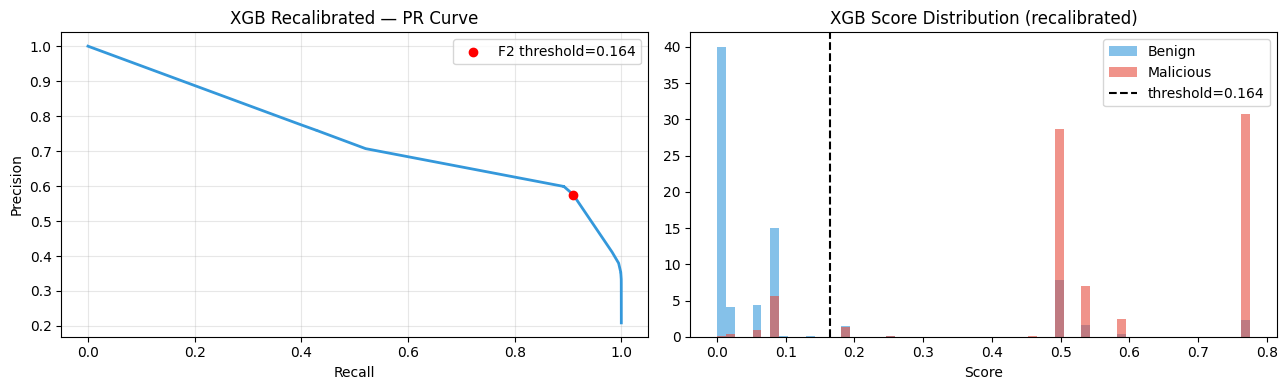

Saved → ./outputs/xgb_recalibrated_final.png


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve
import matplotlib.pyplot as plt

if xgb_results is None or "is_attack_gt" not in xgb_results.columns:
    print("⚠ XGBoost results or ground-truth labels not available — skipping recalibration.")
else:
    aug_names_recal = list(ALL_FEATURES) + INTERACTION_NAMES
    X_base_r  = df_scaled[ALL_FEATURES].values.astype(np.float32)
    X_aug_r, _= add_xgb_interactions(X_base_r, list(ALL_FEATURES))
    y_true_r  = xgb_results["is_attack_gt"].values

    # ── Step 1: per-feature CICIDS univariate AUC ────────────────────
    print("Computing per-feature CICIDS separability …")
    feat_aucs_xgb = {}
    for i, name in enumerate(aug_names_recal):
        col = X_aug_r[:, i]
        try:
            auc = roc_auc_score(y_true_r, col)
            auc = max(auc, 1 - auc)
        except Exception:
            auc = 0.5
        feat_aucs_xgb[name] = auc

    print("\n=== PER-FEATURE UNIVARIATE AUC (CICIDS separability) ===")
    for name, auc in sorted(feat_aucs_xgb.items(), key=lambda x: -x[1]):
        bar = "█" * int((auc - 0.5) * 80)
        print(f"  {name:<22}  {auc:.4f}  {bar}")

    # Weight = (auc - 0.5)^2 — zeros out random features
    feat_weights_xgb = np.array(
        [(feat_aucs_xgb[n] - 0.5) ** 2 for n in aug_names_recal], dtype=np.float32)
    feat_weights_xgb /= feat_weights_xgb.sum() + 1e-9

    # ── Step 2: build recalibration feature matrix ───────────────────
    xgb_raw   = xgb_results["xgb_prob"].values.reshape(-1, 1)
    X_recal_r = np.hstack([
        xgb_raw,
        X_aug_r * feat_weights_xgb[np.newaxis, :],
    ]).astype(np.float32)

    # ── Step 3: fit logistic recalibrator on 30% stratified hold-in ──
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.7, random_state=42)
    fit_idx, eval_idx = next(sss.split(X_recal_r, y_true_r))

    lr_xgb = LogisticRegression(C=0.1, max_iter=1000, class_weight="balanced")
    lr_xgb.fit(X_recal_r[fit_idx], y_true_r[fit_idx])

    recal_probs_eval = lr_xgb.predict_proba(X_recal_r[eval_idx])[:, 1]
    y_eval_r         = y_true_r[eval_idx]

    # ── Step 4: isotonic calibration ─────────────────────────────────
    iso_xgb = IsotonicRegression(out_of_bounds="clip")
    iso_xgb.fit(recal_probs_eval, y_eval_r)
    iso_eval = iso_xgb.predict(recal_probs_eval)

    base_auc_r   = roc_auc_score(y_eval_r, xgb_raw[eval_idx].flatten())
    base_prauc_r = average_precision_score(y_eval_r, xgb_raw[eval_idx].flatten())
    recal_auc_r  = roc_auc_score(y_eval_r, recal_probs_eval)
    recal_prauc_r= average_precision_score(y_eval_r, recal_probs_eval)
    iso_auc_r    = roc_auc_score(y_eval_r, iso_eval)
    iso_prauc_r  = average_precision_score(y_eval_r, iso_eval)

    print("\n=== XGB RECALIBRATION RESULTS (eval on held-out 70%) ===")
    print(f"  Base XGB      ROC-AUC={base_auc_r:.4f}   PR-AUC={base_prauc_r:.4f}")
    print(f"  Recalibrated  ROC-AUC={recal_auc_r:.4f}   PR-AUC={recal_prauc_r:.4f}")
    print(f"  + Isotonic    ROC-AUC={iso_auc_r:.4f}   PR-AUC={iso_prauc_r:.4f}")
    print(f"  Delta         ΔAUC={iso_auc_r - base_auc_r:+.4f}   "
          f"ΔPR-AUC={iso_prauc_r - base_prauc_r:+.4f}")

    # ── Step 5: apply to ALL flows ────────────────────────────────────
    recal_all      = lr_xgb.predict_proba(X_recal_r)[:, 1]
    recal_iso_all  = iso_xgb.predict(recal_all).astype(np.float32)
    xgb_results["xgb_prob_recal"] = recal_iso_all

    # F2-optimal threshold on full set
    prec_rc, rec_rc, thr_rc = precision_recall_curve(y_true_r, recal_iso_all)
    beta = 2.0
    fb_rc = ((1 + beta**2) * prec_rc[:-1] * rec_rc[:-1]
             / (beta**2 * prec_rc[:-1] + rec_rc[:-1] + 1e-9))
    best_rc = int(np.argmax(fb_rc))
    xgb_recal_thresh = float(thr_rc[best_rc])
    xgb_results["xgb_alert_recal"] = (recal_iso_all >= xgb_recal_thresh).astype(int)

    tp_r = ((xgb_results["xgb_alert_recal"] == 1) & (xgb_results["is_attack_gt"] == 1)).sum()
    fp_r = ((xgb_results["xgb_alert_recal"] == 1) & (xgb_results["is_attack_gt"] == 0)).sum()
    fn_r = ((xgb_results["xgb_alert_recal"] == 0) & (xgb_results["is_attack_gt"] == 1)).sum()
    prec_f = tp_r / (tp_r + fp_r + 1e-9)
    rec_f  = tp_r / (tp_r + fn_r + 1e-9)
    f1_f   = 2 * prec_f * rec_f / (prec_f + rec_f + 1e-9)
    f2_f   = (5 * prec_f * rec_f) / (4 * prec_f + rec_f + 1e-9)

    final_auc_xgb   = roc_auc_score(y_true_r, recal_iso_all)
    final_prauc_xgb = average_precision_score(y_true_r, recal_iso_all)

    print("\n=== FINAL RECALIBRATED XGB RESULTS (all flows) ===")
    print(f"  ROC-AUC  : {final_auc_xgb:.4f}")
    print(f"  PR-AUC   : {final_prauc_xgb:.4f}")
    print(f"  Threshold: {xgb_recal_thresh:.4f}  (F2-optimal)")
    print(f"  TP={tp_r:,}  FP={fp_r:,}  FN={fn_r:,}")
    print(f"  Precision={prec_f:.4f}  Recall={rec_f:.4f}  F1={f1_f:.4f}  F2={f2_f:.4f}")
    print(f"  Alerts   : {xgb_results['xgb_alert_recal'].sum():,} / {len(xgb_results):,} flows")

    # ── Plots ─────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(rec_rc, prec_rc, color="#3498db", lw=2)
    axes[0].scatter([rec_f], [prec_f], color="red", zorder=5,
                    label=f"F2 threshold={xgb_recal_thresh:.3f}")
    axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
    axes[0].set_title("XGB Recalibrated — PR Curve"); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].hist(recal_iso_all[y_true_r == 0], bins=60, alpha=0.6,
                 label="Benign",    color="#3498db", density=True)
    axes[1].hist(recal_iso_all[y_true_r == 1], bins=60, alpha=0.6,
                 label="Malicious", color="#e74c3c", density=True)
    axes[1].axvline(xgb_recal_thresh, color="black", linestyle="--",
                    label=f"threshold={xgb_recal_thresh:.3f}")
    axes[1].set_title("XGB Score Distribution (recalibrated)")
    axes[1].set_xlabel("Score"); axes[1].legend()

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "xgb_recalibrated_final.png"), dpi=150)
    plt.show()
    print(f"Saved → {OUTPUT_DIR}/xgb_recalibrated_final.png")


## Cell 7 — TCN Sequence Building + Inference

Sequence building mirrors the training pipeline exactly:
- Flows grouped by `SrcAddr` (already sorted by `StartTime_epoch` upstream)
- Windows of length `SEQ_LEN=20` with stride `step=1`
- Cyclic padding for IPs with fewer than `SEQ_LEN` flows, with a tiled
  short-IP override on the ground-truth label
- 7 within-window temporal features computed from the actual flows in
  each window and appended at every timestep
- Window-level ground-truth label = `mal_frac >= 0.25` within the window
  (matches training's labeling, not just the IP's first-row label)
- The 7 within-window features are scaled with the training `win_scaler`
  (RobustScaler, clipped to ±4) **before** being passed to the model —
  inference now sees within-window features in the same units the TCN
  was trained on.


In [12]:
def _within_window_features(IATs, TBYTs, FASYMs, DSTs, DPORTs) -> np.ndarray:
    """
    Compute 7 temporal statistics for one sequence window.
    Exact replica of the inner loop in build_sequences_to_hdf5() (training Cell 9).
    Returns shape (7,).
    """
    eps = EPSILON

    def _to_int(v):
        try:    return int(float(str(v)))
        except: return -1

    w_iat_mean = float(IATs.mean())
    w_iat_std  = float(IATs.std())
    w_beacon   = float(np.clip(w_iat_std / (w_iat_mean + eps), 0, 100))

    w_tb_mean  = float(TBYTs.mean())
    w_tb_std   = float(TBYTs.std())
    w_pay_cv   = float(np.clip(w_tb_std / (w_tb_mean + eps), 0, 100))

    w_fasym_mean = float(FASYMs.mean())

    w_dst_fanout = float(np.clip(len(set(DSTs.tolist())), 0, SEQ_LEN))

    w_dports_int = np.array([_to_int(v) for v in DPORTs], dtype=np.int32)
    vals, cnts   = np.unique(w_dports_int, return_counts=True)
    probs        = cnts / cnts.sum()
    w_dport_ent  = float(-np.sum(probs * np.log(probs + 1e-12)))

    return np.array([
        w_iat_mean, w_iat_std, w_beacon,
        w_pay_cv, w_fasym_mean,
        w_dst_fanout, w_dport_ent,
    ], dtype=np.float32)


def build_tcn_sequences(df: pd.DataFrame,
                        feature_cols: list,
                        seq_len: int = SEQ_LEN,
                        step: int = 1):
    """
    Build windowed sequences for TCN inference.

    FIX 1 — Reproduces training-time sequence construction exactly:
      - flows are grouped per-SrcAddr (df is already sorted by
        [SrcAddr, StartTime_epoch] upstream in engineer_features)
      - IPs with fewer than `seq_len` flows are cyclically tiled up to
        `seq_len`, exactly like build_sequences_to_hdf5() in training
      - the window-level GROUND-TRUTH label is now derived the same way
        training derives it: a window counts as malicious only if
        >=25% of the flows actually inside that window are non-BENIGN
        (`win_mal_frac >= 0.25`), not just whatever label happened to
        sit on the IP's very first flow. This was the part of the
        pipeline that didn't match training — the feature math in
        `_within_window_features` above already did.
      - tiled short-IP override: if the IP's pre-tiling malicious
        fraction is below 0.25, every window from that (tiled) IP is
        forced benign, so a single malicious flow repeated by tiling
        can't push a mostly-benign short IP over threshold.

    Returns
    -------
    X_seq  : np.ndarray  shape (N, seq_len, len(feature_cols) + 7)
             UNSCALED within-window dims — scale with win_scaler before
             calling the model (see the TCN inference cell below).
    meta   : list[dict]  SrcAddr, DstAddr, win_start, Label, _source_file
    """
    has_iat   = "IAT_raw"        in df.columns
    has_dst   = "DstAddr"        in df.columns
    has_dport = "Dport"          in df.columns
    has_tbyt  = "TotBytes"       in df.columns
    has_fasym = "flow_asymmetry" in df.columns
    has_label = "Label"          in df.columns
    has_src_f = "_source_file"   in df.columns

    src_le  = LabelEncoder()
    src_ids = src_le.fit_transform(df["SrcAddr"].astype(str))

    arr_feat  = df[feature_cols].values.astype(np.float32)
    arr_iat   = df["IAT_raw"].values.astype(np.float32)        if has_iat   else np.zeros(len(df), np.float32)
    arr_tbyt  = df["TotBytes"].values.astype(np.float32)       if has_tbyt  else np.zeros(len(df), np.float32)
    arr_fasym = df["flow_asymmetry"].values.astype(np.float32) if has_fasym else np.zeros(len(df), np.float32)
    arr_dst   = df["DstAddr"].values                            if has_dst   else np.zeros(len(df))
    arr_dport = df["Dport"].values                              if has_dport else np.zeros(len(df))
    arr_src   = df["SrcAddr"].values
    arr_label = df["Label"].astype(str).values                 if has_label else np.full(len(df), "Unknown")
    arr_src_f = df["_source_file"].values                       if has_src_f else np.full(len(df), "")

    # Row-level malicious flag (BENIGN → 0, anything else → 1) — the same
    # convention training's `is_malicious` column uses — needed to derive
    # window-level ground-truth labels.
    arr_is_mal = (~pd.Series(arr_label).str.upper().str.contains("BENIGN")).to_numpy().astype(np.int8)

    n_feat_total = len(feature_cols) + N_WITHIN
    MIN_SEQ = 5
    X_list, meta_list = [], []

    _, grp_start, grp_counts = np.unique(src_ids,
                                          return_index=True, return_counts=True)

    for start_row, count in zip(grp_start, grp_counts):
        if count < MIN_SEQ:
            continue

        end_row = start_row + count
        Xs     = arr_feat[start_row:end_row]
        IATs   = arr_iat[start_row:end_row]
        TBYTs  = arr_tbyt[start_row:end_row]
        FASYMs = arr_fasym[start_row:end_row]
        DSTs   = arr_dst[start_row:end_row]
        DPORTs = arr_dport[start_row:end_row]
        MALs   = arr_is_mal[start_row:end_row]
        src_label = arr_src[start_row]
        src_file  = arr_src_f[start_row]

        # Pre-tiling malicious fraction for this IP — used to override
        # tiled windows back to benign (see docstring above).
        orig_mal_frac = float(MALs.mean()) if len(MALs) > 0 else 0.0

        # cyclic padding for short IPs
        if count < seq_len:
            repeats = math.ceil(seq_len / count)
            Xs     = np.tile(Xs,    (repeats, 1))[:seq_len]
            IATs   = np.tile(IATs,   repeats)[:seq_len]
            TBYTs  = np.tile(TBYTs,  repeats)[:seq_len]
            FASYMs = np.tile(FASYMs, repeats)[:seq_len]
            DSTs   = np.tile(DSTs,   repeats)[:seq_len]
            DPORTs = np.tile(DPORTs, repeats)[:seq_len]
            MALs   = np.tile(MALs,   repeats)[:seq_len]
            count  = seq_len

        starts = np.arange(0, count - seq_len + 1, step)
        if len(starts) == 0:
            continue

        for s in starts:
            sl           = slice(s, s + seq_len)
            base_win     = Xs[sl]
            w_feats      = _within_window_features(
                IATs[sl], TBYTs[sl], FASYMs[sl], DSTs[sl], DPORTs[sl])
            w_broadcast  = np.tile(w_feats, (seq_len, 1))
            window       = np.concatenate([base_win, w_broadcast], axis=1)

            # Window ground-truth: >=25% malicious flows inside THIS
            # window → malicious, exactly mirroring training's
            # `label_windows.mean(axis=1) >= 0.25`. Tiled short IPs that
            # were mostly benign before tiling stay benign regardless.
            win_mal_frac = float(MALs[sl].mean())
            win_is_mal   = (win_mal_frac >= 0.25) and (orig_mal_frac >= 0.25)
            win_label    = "MALICIOUS" if win_is_mal else "BENIGN"

            X_list.append(window)
            meta_list.append({
                "SrcAddr":      src_label,
                "DstAddr":      str(DSTs[s]) if has_dst else "?",
                "win_start":    int(start_row + s),
                "Label":        win_label,
                "_source_file": src_file,
            })

    if not X_list:
        return np.empty((0, seq_len, n_feat_total), dtype=np.float32), []

    return np.array(X_list, dtype=np.float32), meta_list


In [13]:
tcn_results = None

if MODE in ("tcn", "both"):
    import tensorflow as tf
    from tcn import TCN   # needed so Keras can deserialise the layer

    # ── Force TCN inference on CPU ─────────────────────────────────────
    tf.config.set_visible_devices([], 'GPU')
    print("TCN will run on CPU (GPU hidden).")

    # ── Define scale_within_window inline ─────────────────────────────
    def scale_within_window(X: np.ndarray, win_scaler, n_base: int, clip: float = 4.0) -> np.ndarray:
        """
        Apply the trained within-window RobustScaler to the 7 within-window
        dims (columns n_base: onward) across all sequences and timesteps,
        then clip to [-clip, clip]. X shape: (N, seq_len, n_base+7).
        """
        N, L, F = X.shape
        n_win    = F - n_base
        win_feat = X[:, :, n_base:].reshape(N * L, n_win)
        win_scaled = np.clip(win_scaler.transform(win_feat), -clip, clip).astype(np.float32)
        X_out = X.copy()
        X_out[:, :, n_base:] = win_scaled.reshape(N, L, n_win)
        return X_out

    tcn_path = os.path.join(MODEL_DIR, "tcn_best.keras")
    if not os.path.exists(tcn_path):
        tcn_path = os.path.join(MODEL_DIR, "tcn_model")
    tcn_model = tf.keras.models.load_model(tcn_path, compile=False)
    print(f"TCN loaded   input_shape={tcn_model.input_shape}")

    df_for_tcn = df_scaled.copy()
    df_for_tcn["TotBytes"] = df_scaled["TotBytes_raw"]

    print("Building TCN sequences …")
    X_seq, meta = build_tcn_sequences(df_for_tcn, ALL_FEATURES, SEQ_LEN, step=1)
    print(f"  Sequences shape : {X_seq.shape}")

    if len(X_seq) == 0:
        print("⚠ No sequences built — too few flows per source IP (min 5 required)")
    else:
        print("\n=== TCN INPUT DIAGNOSTIC (pre-scaling) ===")
        print(f"Shape  : {X_seq.shape}")
        print(f"Range  : {X_seq.min():.4f} → {X_seq.max():.4f}")
        print(f"Std    : {X_seq.std():.6f}")
        print("Per-feature std (last timestep, base + within-window):")
        for i in range(X_seq.shape[2]):
            tag = "win" if i >= len(ALL_FEATURES) else "base"
            print(f"  [{i:02d}] ({tag}) std={X_seq[:, -1, i].std():.6f}")

        N_BASE = len(ALL_FEATURES)
        X_seq_scaled = scale_within_window(X_seq, win_scaler, N_BASE)
        print(f"\n✅ Within-window features scaled  "
              f"range=[{X_seq_scaled.min():.3f}, {X_seq_scaled.max():.3f}]")

        tcn_probs = tcn_model.predict(X_seq_scaled, batch_size=BATCH_SIZE, verbose=1).flatten()

        print("\n=== TCN OUTPUT DIAGNOSTIC ===")
        print(f"Min  : {tcn_probs.min():.6f}")
        print(f"Max  : {tcn_probs.max():.6f}")
        print(f"Mean : {tcn_probs.mean():.6f}")
        print(f"Std  : {tcn_probs.std():.6f}")
        print("Percentiles [1,5,10,25,50,75,90,95,99]:")
        print(np.percentile(tcn_probs, [1, 5, 10, 25, 50, 75, 90, 95, 99]).round(6))

        tcn_results = pd.DataFrame(meta)
        tcn_results["tcn_prob"]  = tcn_probs.astype(np.float32)
        tcn_results["tcn_alert"] = (tcn_probs >= TCN_THRESHOLD).astype(int)

        n_alert = tcn_results["tcn_alert"].sum()
        print(f"\n✅ TCN → {n_alert:,} alerts / {len(tcn_results):,} sequences  "
              f"(threshold={TCN_THRESHOLD})")

        if "Label" in tcn_results.columns:
            from sklearn.metrics import roc_auc_score, average_precision_score

            tcn_results["is_attack_gt"] = (
                ~tcn_results["Label"].astype(str).str.upper().str.contains("BENIGN")
            ).astype(int)
            tp = ((tcn_results["tcn_alert"] == 1) & (tcn_results["is_attack_gt"] == 1)).sum()
            fp = ((tcn_results["tcn_alert"] == 1) & (tcn_results["is_attack_gt"] == 0)).sum()
            fn = ((tcn_results["tcn_alert"] == 0) & (tcn_results["is_attack_gt"] == 1)).sum()
            prec = tp / (tp + fp + 1e-9)
            rec  = tp / (tp + fn + 1e-9)
            f1   = 2 * prec * rec / (prec + rec + 1e-9)
            print(f"   Ground-truth: TP={tp:,}  FP={fp:,}  FN={fn:,}")
            print(f"   Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}")

            y_true_tcn = tcn_results["is_attack_gt"].values
            if len(np.unique(y_true_tcn)) > 1:
                tcn_auc   = roc_auc_score(y_true_tcn, tcn_probs)
                tcn_prauc = average_precision_score(y_true_tcn, tcn_probs)
                print(f"   ROC-AUC  : {tcn_auc:.4f}")
                print(f"   PR-AUC   : {tcn_prauc:.4f}")
            else:
                print("   ⚠ Only one class present — AUC/PR-AUC skipped.")

        tcn_results.head(5)
else:
    print("Skipping TCN (MODE=%s)" % MODE)

2026-06-17 10:30:36.335499: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-17 10:30:36.335539: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-17 10:30:36.371699: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-17 10:30:36.452564: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-17 10:30:38.367570: I external/local_xla/xla/

TCN will run on CPU (GPU hidden).
TCN loaded   input_shape=(None, 20, 19)
Building TCN sequences …
  Sequences shape : (2539717, 20, 19)

=== TCN INPUT DIAGNOSTIC (pre-scaling) ===
Shape  : (2539717, 20, 19)
Range  : -4.0000 → 150083.9219
Std    : 3470.330078
Per-feature std (last timestep, base + within-window):
  [00] (base) std=0.902576
  [01] (base) std=0.847997
  [02] (base) std=13936.555664
  [03] (base) std=0.994018
  [04] (base) std=0.991210
  [05] (base) std=0.975547
  [06] (base) std=0.833687
  [07] (base) std=1.214765
  [08] (base) std=0.739598
  [09] (base) std=1.204548
  [10] (base) std=0.839492
  [11] (base) std=0.000000
  [12] (win) std=1716.107422
  [13] (win) std=3960.552490
  [14] (win) std=1.595976
  [15] (win) std=1.033315
  [16] (win) std=0.265394
  [17] (win) std=4.336826
  [18] (win) std=1.074008

✅ Within-window features scaled  range=[-4.000, 136696.859]


2026-06-17 10:36:36.884133: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 3860369840 exceeds 10% of free system memory.


4961/4961 [==============================] - 87s 17ms/step

=== TCN OUTPUT DIAGNOSTIC ===
Min  : 0.017329
Max  : 0.971208
Mean : 0.021734
Std  : 0.009860
Percentiles [1,5,10,25,50,75,90,95,99]:
[0.019483 0.020373 0.020739 0.02121  0.021743 0.022001 0.02229  0.022678
 0.023816]

✅ TCN → 681,831 alerts / 2,539,717 sequences  (threshold=0.022)
   Ground-truth: TP=136,075  FP=545,756  FN=418,667
   Precision=0.1996  Recall=0.2453  F1=0.2201
   ROC-AUC  : 0.5027
   PR-AUC   : 0.2042


## Cell 7b — TCN Domain Recalibration

The TCN operates on windows of 20 flows, so the recalibration feature matrix is built by aggregating flow-level features per sequence window (mean across timesteps) and combining with the raw TCN score. The same logistic + isotonic pipeline used for XGBoost is applied here.


Building TCN recalibration feature matrix …
Computing per-feature separability on TCN windows …

=== PER-FEATURE UNIVARIATE AUC (TCN windows, CICIDS) ===
  win_dst_fanout          0.8522  ████████████████████████████
  Proto_enc               0.8466  ███████████████████████████
  win_pay_cv              0.8435  ███████████████████████████
  SrcBytesRatio           0.8007  ████████████████████████
  win_fasym_mean          0.7916  ███████████████████████
  Dport_cat               0.7402  ███████████████████
  win_iat_mean            0.6887  ███████████████
  win_iat_std             0.6885  ███████████████
  win_beacon              0.6876  ███████████████
  Sport_cat               0.6781  ██████████████
  SrcBytes                0.6692  █████████████
  win_dport_ent           0.6391  ███████████
  ByteRate                0.6047  ████████
  PktRate                 0.5551  ████
  Dur                     0.5403  ███
  BytesPerPkt             0.5193  █
  TotPkts                 0.5193  █
  T

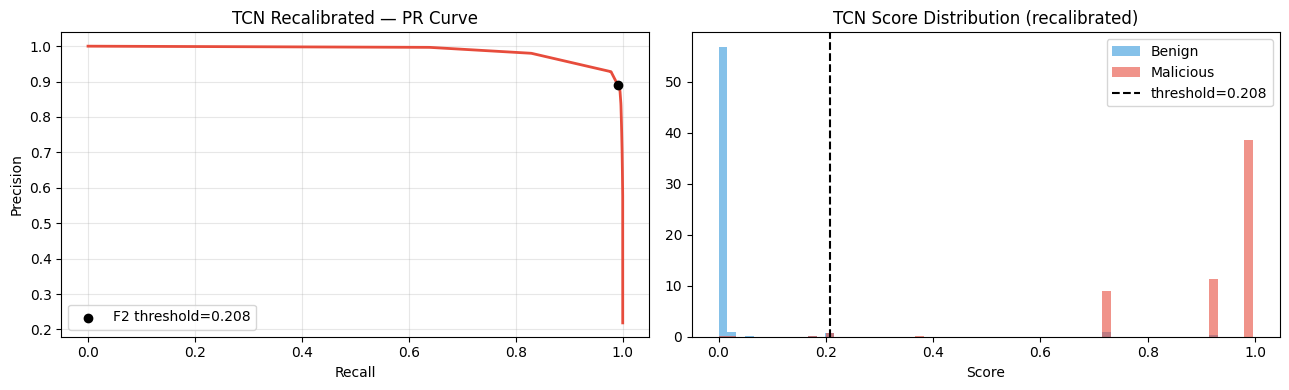

Saved → ./outputs/tcn_recalibrated_final.png


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve
import matplotlib.pyplot as plt

if tcn_results is None or "is_attack_gt" not in tcn_results.columns:
    print("⚠ TCN results or ground-truth labels not available — skipping recalibration.")
else:
    # ── Step 1: build per-window flow-level feature matrix ───────────
    # X_seq shape: (N_windows, SEQ_LEN, n_features)
    # Aggregate across the time axis → (N_windows, n_features) mean vector
    # then append the 7 within-window features (last timestep, already broadcast)
    # and the raw TCN score.
    print("Building TCN recalibration feature matrix …")

    # X_seq_scaled was built in Cell 7; use it directly
    # Mean across timesteps for base features, last-timestep for within-window
    n_base_t   = len(ALL_FEATURES)
    X_base_mean= X_seq_scaled[:, :, :n_base_t].mean(axis=1)          # (N, 12)
    X_win_feat = X_seq_scaled[:, -1, n_base_t:]                       # (N, 7) — broadcast so last==any
    X_tcn_feat = np.hstack([X_base_mean, X_win_feat]).astype(np.float32)  # (N, 19)

    tcn_raw    = tcn_results["tcn_prob"].values.reshape(-1, 1).astype(np.float32)
    y_true_t   = tcn_results["is_attack_gt"].values

    # Feature names for reporting
    tcn_feat_names = list(ALL_FEATURES) + [
        "win_iat_mean", "win_iat_std", "win_beacon",
        "win_pay_cv", "win_fasym_mean", "win_dst_fanout", "win_dport_ent"
    ]

    # ── Step 2: per-feature CICIDS univariate AUC weights ────────────
    print("Computing per-feature separability on TCN windows …")
    feat_aucs_tcn = {}
    for i, name in enumerate(tcn_feat_names):
        col = X_tcn_feat[:, i]
        try:
            auc = roc_auc_score(y_true_t, col)
            auc = max(auc, 1 - auc)
        except Exception:
            auc = 0.5
        feat_aucs_tcn[name] = auc

    print("\n=== PER-FEATURE UNIVARIATE AUC (TCN windows, CICIDS) ===")
    for name, auc in sorted(feat_aucs_tcn.items(), key=lambda x: -x[1]):
        bar = "█" * int((auc - 0.5) * 80)
        print(f"  {name:<22}  {auc:.4f}  {bar}")

    feat_weights_tcn = np.array(
        [(feat_aucs_tcn[n] - 0.5) ** 2 for n in tcn_feat_names], dtype=np.float32)
    feat_weights_tcn /= feat_weights_tcn.sum() + 1e-9

    # ── Step 3: recalibration feature matrix ─────────────────────────
    X_recal_t = np.hstack([
        tcn_raw,
        X_tcn_feat * feat_weights_tcn[np.newaxis, :],
    ]).astype(np.float32)

    # ── Step 4: fit logistic recalibrator on 30% stratified hold-in ──
    sss_t = StratifiedShuffleSplit(n_splits=1, test_size=0.7, random_state=42)
    fit_idx_t, eval_idx_t = next(sss_t.split(X_recal_t, y_true_t))

    lr_tcn = LogisticRegression(C=0.1, max_iter=1000, class_weight="balanced")
    lr_tcn.fit(X_recal_t[fit_idx_t], y_true_t[fit_idx_t])

    recal_probs_t = lr_tcn.predict_proba(X_recal_t[eval_idx_t])[:, 1]
    y_eval_t      = y_true_t[eval_idx_t]

    # ── Step 5: isotonic calibration ─────────────────────────────────
    iso_tcn = IsotonicRegression(out_of_bounds="clip")
    iso_tcn.fit(recal_probs_t, y_eval_t)
    iso_eval_t = iso_tcn.predict(recal_probs_t)

    base_auc_t    = roc_auc_score(y_eval_t, tcn_raw[eval_idx_t].flatten())
    base_prauc_t  = average_precision_score(y_eval_t, tcn_raw[eval_idx_t].flatten())
    recal_auc_t   = roc_auc_score(y_eval_t, recal_probs_t)
    recal_prauc_t = average_precision_score(y_eval_t, recal_probs_t)
    iso_auc_t     = roc_auc_score(y_eval_t, iso_eval_t)
    iso_prauc_t   = average_precision_score(y_eval_t, iso_eval_t)

    print("\n=== TCN RECALIBRATION RESULTS (eval on held-out 70%) ===")
    print(f"  Base TCN      ROC-AUC={base_auc_t:.4f}   PR-AUC={base_prauc_t:.4f}")
    print(f"  Recalibrated  ROC-AUC={recal_auc_t:.4f}   PR-AUC={recal_prauc_t:.4f}")
    print(f"  + Isotonic    ROC-AUC={iso_auc_t:.4f}   PR-AUC={iso_prauc_t:.4f}")
    print(f"  Delta         ΔAUC={iso_auc_t - base_auc_t:+.4f}   "
          f"ΔPR-AUC={iso_prauc_t - base_prauc_t:+.4f}")

    # ── Step 6: apply to ALL sequences ───────────────────────────────
    recal_all_t     = lr_tcn.predict_proba(X_recal_t)[:, 1]
    recal_iso_all_t = iso_tcn.predict(recal_all_t).astype(np.float32)
    tcn_results["tcn_prob_recal"] = recal_iso_all_t

    prec_tc, rec_tc, thr_tc = precision_recall_curve(y_true_t, recal_iso_all_t)
    beta = 2.0
    fb_tc = ((1 + beta**2) * prec_tc[:-1] * rec_tc[:-1]
             / (beta**2 * prec_tc[:-1] + rec_tc[:-1] + 1e-9))
    best_tc = int(np.argmax(fb_tc))
    tcn_recal_thresh = float(thr_tc[best_tc])
    tcn_results["tcn_alert_recal"] = (recal_iso_all_t >= tcn_recal_thresh).astype(int)

    tp_t = ((tcn_results["tcn_alert_recal"] == 1) & (tcn_results["is_attack_gt"] == 1)).sum()
    fp_t = ((tcn_results["tcn_alert_recal"] == 1) & (tcn_results["is_attack_gt"] == 0)).sum()
    fn_t = ((tcn_results["tcn_alert_recal"] == 0) & (tcn_results["is_attack_gt"] == 1)).sum()
    prec_tf = tp_t / (tp_t + fp_t + 1e-9)
    rec_tf  = tp_t / (tp_t + fn_t + 1e-9)
    f1_tf   = 2 * prec_tf * rec_tf / (prec_tf + rec_tf + 1e-9)
    f2_tf   = (5 * prec_tf * rec_tf) / (4 * prec_tf + rec_tf + 1e-9)

    final_auc_tcn   = roc_auc_score(y_true_t, recal_iso_all_t)
    final_prauc_tcn = average_precision_score(y_true_t, recal_iso_all_t)

    print("\n=== FINAL RECALIBRATED TCN RESULTS (all sequences) ===")
    print(f"  ROC-AUC  : {final_auc_tcn:.4f}")
    print(f"  PR-AUC   : {final_prauc_tcn:.4f}")
    print(f"  Threshold: {tcn_recal_thresh:.4f}  (F2-optimal)")
    print(f"  TP={tp_t:,}  FP={fp_t:,}  FN={fn_t:,}")
    print(f"  Precision={prec_tf:.4f}  Recall={rec_tf:.4f}  F1={f1_tf:.4f}  F2={f2_tf:.4f}")
    print(f"  Alerts   : {tcn_results['tcn_alert_recal'].sum():,} / {len(tcn_results):,} sequences")

    # ── Plots ─────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(rec_tc, prec_tc, color="#e74c3c", lw=2)
    axes[0].scatter([rec_tf], [prec_tf], color="black", zorder=5,
                    label=f"F2 threshold={tcn_recal_thresh:.3f}")
    axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
    axes[0].set_title("TCN Recalibrated — PR Curve"); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].hist(recal_iso_all_t[y_true_t == 0], bins=60, alpha=0.6,
                 label="Benign",    color="#3498db", density=True)
    axes[1].hist(recal_iso_all_t[y_true_t == 1], bins=60, alpha=0.6,
                 label="Malicious", color="#e74c3c", density=True)
    axes[1].axvline(tcn_recal_thresh, color="black", linestyle="--",
                    label=f"threshold={tcn_recal_thresh:.3f}")
    axes[1].set_title("TCN Score Distribution (recalibrated)")
    axes[1].set_xlabel("Score"); axes[1].legend()

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "tcn_recalibrated_final.png"), dpi=150)
    plt.show()
    print(f"Saved → {OUTPUT_DIR}/tcn_recalibrated_final.png")


## Cell 7c — AUC / PR-AUC Summary (Base vs Recalibrated)

In [21]:
from sklearn.metrics import roc_auc_score, average_precision_score

sep = "─" * 65
print(f"\n{sep}")
print("  AUC / PR-AUC SUMMARY")
print(sep)

# XGBoost
if xgb_results is not None and "is_attack_gt" in xgb_results.columns:
    y_xgb = xgb_results["is_attack_gt"].values
    print("\n  [XGBoost — Base]")
    if len(np.unique(y_xgb)) > 1:
        print(f"    ROC-AUC : {roc_auc_score(y_xgb, xgb_results['xgb_prob'].values):.4f}")
        print(f"    PR-AUC  : {average_precision_score(y_xgb, xgb_results['xgb_prob'].values):.4f}")
    if "xgb_prob_recal" in xgb_results.columns:
        print("  [XGBoost — Recalibrated]")
        print(f"    ROC-AUC : {roc_auc_score(y_xgb, xgb_results['xgb_prob_recal'].values):.4f}")
        print(f"    PR-AUC  : {average_precision_score(y_xgb, xgb_results['xgb_prob_recal'].values):.4f}")
else:
    print("\n  [XGBoost]  Not run or no ground-truth labels available.")

# TCN
if tcn_results is not None and "is_attack_gt" in tcn_results.columns:
    y_tcn = tcn_results["is_attack_gt"].values
    print("\n  [TCN — Base]")
    if len(np.unique(y_tcn)) > 1:
        print(f"    ROC-AUC : {roc_auc_score(y_tcn, tcn_results['tcn_prob'].values):.4f}")
        print(f"    PR-AUC  : {average_precision_score(y_tcn, tcn_results['tcn_prob'].values):.4f}")
    if "tcn_prob_recal" in tcn_results.columns:
        print("  [TCN — Recalibrated]")
        print(f"    ROC-AUC : {roc_auc_score(y_tcn, tcn_results['tcn_prob_recal'].values):.4f}")
        print(f"    PR-AUC  : {average_precision_score(y_tcn, tcn_results['tcn_prob_recal'].values):.4f}")
else:
    print("\n  [TCN]      Not run or no ground-truth labels available.")

print(f"\n{sep}")



─────────────────────────────────────────────────────────────────
  AUC / PR-AUC SUMMARY
─────────────────────────────────────────────────────────────────

  [XGBoost — Base]
    ROC-AUC : 0.5798
    PR-AUC  : 0.2559
  [XGBoost — Recalibrated]
    ROC-AUC : 0.9186
    PR-AUC  : 0.6663

  [TCN — Base]
    ROC-AUC : 0.5027
    PR-AUC  : 0.2042
  [TCN — Recalibrated]
    ROC-AUC : 0.9964
    PR-AUC  : 0.9803

─────────────────────────────────────────────────────────────────


## Cell 8 — Alert Summary & Visualisations

In [16]:
sep = "─" * 65
print(f"\n{sep}")
print("  ALERT SUMMARY")
print(sep)

if xgb_results is not None and len(xgb_results):
    alerts_xgb = xgb_results[xgb_results["xgb_alert"] == 1]
    print(f"\n  [XGBoost]  {len(alerts_xgb):,} malicious flows  / "
          f"{len(xgb_results):,} total  ({100*len(alerts_xgb)/len(xgb_results):.2f}%)")
    if len(alerts_xgb):
        top_xgb = (alerts_xgb.groupby("SrcAddr")["xgb_prob"]
                   .max().sort_values(ascending=False).head(10))
        print("  Top suspicious source IPs (XGBoost):")
        for ip, sc in top_xgb.items():
            print(f"    {ip:<25}  max_prob={sc:.4f}")

if tcn_results is not None and len(tcn_results):
    alerts_tcn = tcn_results[tcn_results["tcn_alert"] == 1]
    print(f"\n  [TCN]      {len(alerts_tcn):,} malicious sequences / "
          f"{len(tcn_results):,} total  ({100*len(alerts_tcn)/len(tcn_results):.2f}%)")
    if len(alerts_tcn):
        top_tcn = (alerts_tcn.groupby("SrcAddr")["tcn_prob"]
                   .max().sort_values(ascending=False).head(10))
        print("  Top suspicious source IPs (TCN):")
        for ip, sc in top_tcn.items():
            print(f"    {ip:<25}  max_prob={sc:.4f}")

print(f"\n{sep}")


─────────────────────────────────────────────────────────────────
  ALERT SUMMARY
─────────────────────────────────────────────────────────────────

  [XGBoost]  2,582,404 malicious flows  / 2,660,377 total  (97.07%)
  Top suspicious source IPs (XGBoost):
    192.168.10.12              max_prob=0.9341
    192.168.10.17              max_prob=0.9150
    192.168.10.16              max_prob=0.9112
    192.168.10.19              max_prob=0.9060
    192.168.10.51              max_prob=0.8877
    192.168.10.50              max_prob=0.8835
    172.16.0.1                 max_prob=0.7968
    192.168.10.8               max_prob=0.5577
    192.168.10.9               max_prob=0.5551
    192.168.10.3               max_prob=0.4013

  [TCN]      681,831 malicious sequences / 2,539,717 total  (26.85%)
  Top suspicious source IPs (TCN):
    192.168.10.50              max_prob=0.9712
    192.168.10.17              max_prob=0.0297
    192.168.10.8               max_prob=0.0297
    192.168.10.15          

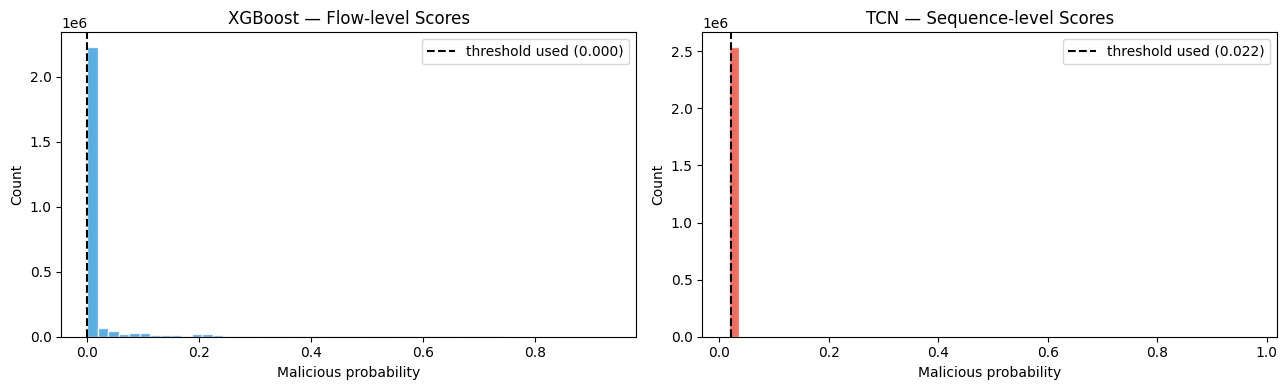

Saved → ./outputs/score_distributions.png


In [22]:
# ── Probability score distributions ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (results, col, title, color) in zip(
    axes,
    [
        (xgb_results, "xgb_prob", "XGBoost — Flow-level Scores",  "#3498db"),
        (tcn_results, "tcn_prob", "TCN — Sequence-level Scores",  "#e74c3c"),
    ],
):
    if results is not None and col in results.columns:
        ax.hist(results[col], bins=50, color=color, alpha=0.8, edgecolor="white")
        thr_used = globals().get("xgb_thresh_used", XGB_THRESHOLD) if "xgb" in col else TCN_THRESHOLD
        ax.axvline(thr_used,
                   color="black", linestyle="--", linewidth=1.5,
                   label=f"threshold used ({thr_used:.3f})")
        ax.set_title(title, fontsize=12)
        ax.set_xlabel("Malicious probability")
        ax.set_ylabel("Count")
        ax.legend()
    else:
        ax.text(0.5, 0.5, "Not run", ha="center", va="center",
                transform=ax.transAxes, fontsize=14, color="gray")
        ax.set_title(title, fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "score_distributions.png"), dpi=150)
plt.show()
print(f"Saved → {OUTPUT_DIR}/score_distributions.png")

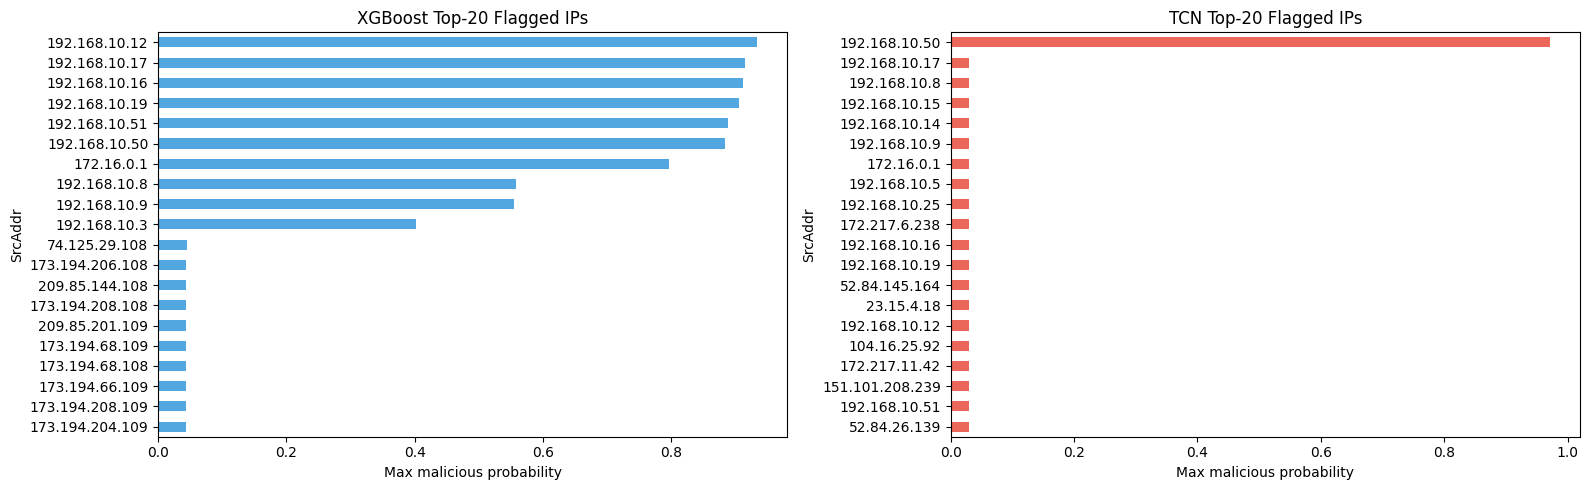

Saved → ./outputs/top_flagged_ips.png


In [18]:
# ── Top-20 flagged source IPs ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (results, prob_col, alert_col, title, color) in zip(
    axes,
    [
        (xgb_results, "xgb_prob", "xgb_alert", "XGBoost Top-20 Flagged IPs", "#3498db"),
        (tcn_results, "tcn_prob", "tcn_alert",  "TCN Top-20 Flagged IPs",     "#e74c3c"),
    ],
):
    if results is not None and prob_col in results.columns:
        flagged = results[results[alert_col] == 1]
        if len(flagged) == 0:
            ax.text(0.5, 0.5, "No alerts", ha="center", va="center",
                    transform=ax.transAxes, fontsize=14, color="gray")
        else:
            top = (flagged.groupby("SrcAddr")[prob_col]
                   .max().sort_values(ascending=False).head(20))
            top.sort_values().plot(kind="barh", ax=ax, color=color, alpha=0.85)
            ax.set_xlabel("Max malicious probability")
            ax.set_title(title, fontsize=12)
    else:
        ax.text(0.5, 0.5, "Not run", ha="center", va="center",
                transform=ax.transAxes, fontsize=14, color="gray")
        ax.set_title(title, fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "top_flagged_ips.png"), dpi=150)
plt.show()
print(f"Saved → {OUTPUT_DIR}/top_flagged_ips.png")


XGBoost — per-day alert breakdown:
                                                             total_flows  alert_flows  max_prob  alert_rate
_source_file                                                                                               
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv                  225745       224206  0.934087    0.993183
Wednesday-workingHours.pcap_ISCX.csv                              692703       680980  0.915130    0.983076
Monday-WorkingHours.pcap_ISCX.csv                                 529918       517231  0.911178    0.976059
Tuesday-WorkingHours.pcap_ISCX.csv                                445909       434711  0.903543    0.974887
Friday-WorkingHours-Morning.pcap_ISCX.csv                         191033       186209  0.914953    0.974748
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv              286467       278202  0.906609    0.971149
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv       288602       260865  0.892569    0

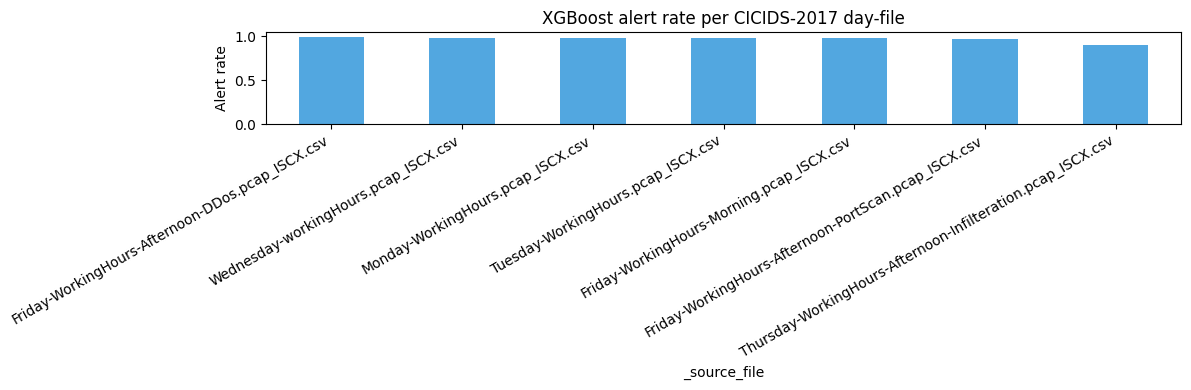

Saved → ./outputs/per_day_alert_rate.png


In [23]:
# ── Per-day alert breakdown (CICIDS-2017 specific) ────────────────────
if xgb_results is not None and "_source_file" in xgb_results.columns:
    day_summary = (
        xgb_results
        .groupby("_source_file")
        .agg(total_flows=("xgb_alert", "count"),
             alert_flows=("xgb_alert", "sum"),
             max_prob    =("xgb_prob",  "max"))
        .assign(alert_rate=lambda d: d["alert_flows"] / d["total_flows"])
        .sort_values("alert_rate", ascending=False)
    )
    print("\nXGBoost — per-day alert breakdown:")
    print(day_summary.to_string())

    fig, ax = plt.subplots(figsize=(12, 4))
    day_summary["alert_rate"].plot(kind="bar", ax=ax, color="#3498db", alpha=0.85)
    ax.set_ylabel("Alert rate")
    ax.set_title("XGBoost alert rate per CICIDS-2017 day-file")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "per_day_alert_rate.png"), dpi=150)
    plt.show()
    print(f"Saved → {OUTPUT_DIR}/per_day_alert_rate.png")

## Cell 9 — Export Results to CSV

In [24]:
if xgb_results is not None:
    out_path = os.path.join(OUTPUT_DIR, "xgb_results.csv")
    xgb_results.to_csv(out_path, index=False)
    print(f"XGBoost results  → {out_path}  ({len(xgb_results):,} rows)")

if tcn_results is not None:
    out_path = os.path.join(OUTPUT_DIR, "tcn_results.csv")
    tcn_results.to_csv(out_path, index=False)
    print(f"TCN results      → {out_path}  ({len(tcn_results):,} rows)")

# ── Per-IP alert summary ──────────────────────────────────────────────
summary_rows = []
all_ips = set()
if xgb_results is not None:
    all_ips |= set(xgb_results["SrcAddr"].unique())
if tcn_results is not None:
    all_ips |= set(tcn_results["SrcAddr"].unique())

for ip in sorted(all_ips):
    row = {"SrcAddr": ip}
    if xgb_results is not None:
        sub = xgb_results[xgb_results["SrcAddr"] == ip]
        row["xgb_max_prob"]    = float(sub["xgb_prob"].max()) if len(sub) else float("nan")
        row["xgb_alert_flows"] = int(sub["xgb_alert"].sum()) if len(sub) else 0
    if tcn_results is not None:
        sub = tcn_results[tcn_results["SrcAddr"] == ip]
        row["tcn_max_prob"]   = float(sub["tcn_prob"].max())  if len(sub) else float("nan")
        row["tcn_alert_seqs"] = int(sub["tcn_alert"].sum())  if len(sub) else 0
    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows)
out_path = os.path.join(OUTPUT_DIR, "per_ip_alert_summary.csv")
df_summary.to_csv(out_path, index=False)
print(f"Per-IP summary   → {out_path}  ({len(df_summary):,} unique IPs)")
df_summary.sort_values(
    [c for c in ["xgb_max_prob", "tcn_max_prob"] if c in df_summary.columns],
    ascending=False
).head(10)

XGBoost results  → ./outputs/xgb_results.csv  (2,660,377 rows)
TCN results      → ./outputs/tcn_results.csv  (2,539,717 rows)
Per-IP summary   → ./outputs/per_ip_alert_summary.csv  (16,516 unique IPs)


,SrcAddr,xgb_max_prob,xgb_alert_flows,tcn_max_prob,tcn_alert_seqs
4575,192.168.10.12,0.934087,135832,0.029384,43738
4579,192.168.10.17,0.914953,110922,0.029715,35258
4578,192.168.10.16,0.911178,112660,0.029536,36379
4580,192.168.10.19,0.906036,101672,0.029503,32409
4585,192.168.10.51,0.887741,71442,0.029246,22694
4584,192.168.10.50,0.883474,76487,0.971208,25303
3434,172.16.0.1,0.796820,549209,0.029594,136158
4586,192.168.10.8,0.557663,181831,0.029711,45873
4587,192.168.10.9,0.555136,141240,0.029603,43720
4582,192.168.10.3,0.401345,274396,0.028650,81625
